Loaded trajectories (deduped per particle/frame):
   frame  particle         x          y        vx        vy
0      0         0  95.70935  201.01486       NaN       NaN
1      1         0  95.66130  200.93707 -0.048050 -0.077789
2      2         0  95.66762  200.96243  0.006317  0.025360
3      3         0  95.69534  201.01556  0.027725  0.053131
4      4         0  95.77921  200.99782  0.083870 -0.017746
Saved cleaned trajectory dataset
Computing ensemble MSD...


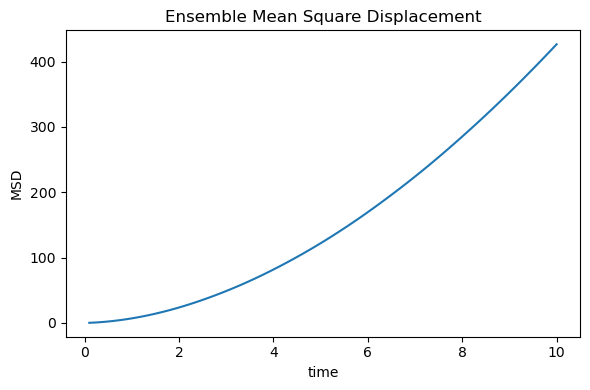

Plotting speed distribution...


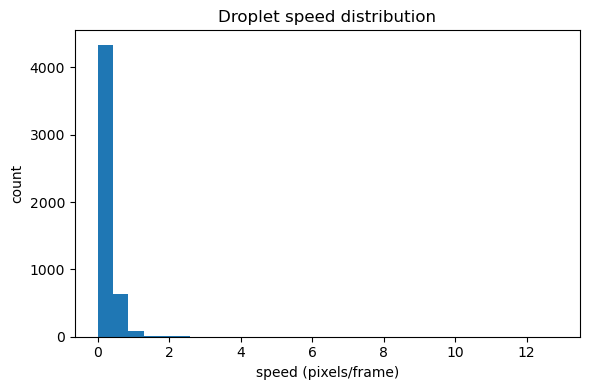

Computing pair distances...


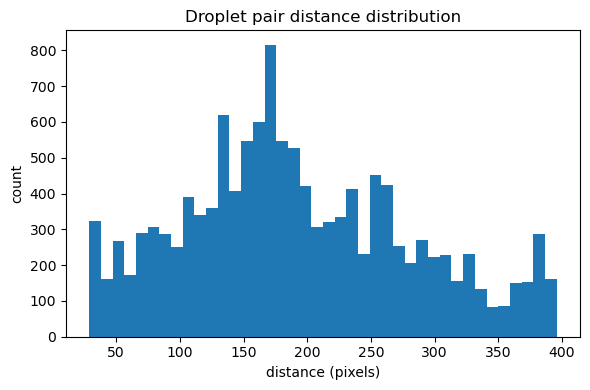

Plotting velocity field...


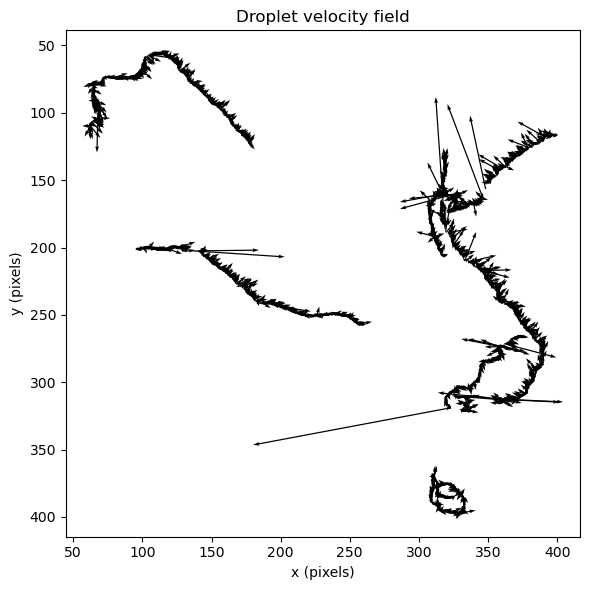

Analysis complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import trackpy as tp
 
# ----------------------------
# Load & clean trajectory data
# ----------------------------

tracks = pd.read_csv("droplet_trajectories.csv")

# keep only rows with valid ids/frames/positions
tracks = tracks.dropna(subset=["particle", "frame", "x", "y"])
tracks["particle"] = tracks["particle"].astype(int)
tracks["frame"] = tracks["frame"].astype(int)

tracks = tracks.sort_values(["particle", "frame"])
tracks = tracks.drop_duplicates(subset=["particle", "frame"], keep="first").reset_index(
    drop=True
)

print("Loaded trajectories (deduped per particle/frame):")
print(tracks.head())

# ----------------------------
# Compute speed
# ----------------------------

tracks["speed"] = np.sqrt(tracks["vx"] ** 2 + tracks["vy"] ** 2)

tracks.to_csv("droplet_trajectories_clean.csv", index=False)

print("Saved cleaned trajectory dataset")

# ----------------------------
# Ensemble Mean Square Displacement
# ----------------------------

print("Computing ensemble MSD...")

# For multiple particles, use emsd (msd is for a single trajectory).
emsd = tp.motion.emsd(tracks, mpp=1, fps=10)

plt.figure(figsize=(6, 4))
plt.plot(emsd.index, emsd.values)
plt.xlabel("time")
plt.ylabel("MSD")
plt.title("Ensemble Mean Square Displacement")
plt.tight_layout()
plt.show()

# ----------------------------
# Speed distribution
# ----------------------------

print("Plotting speed distribution...")

plt.figure(figsize=(6, 4))
plt.hist(tracks["speed"].dropna(), bins=30)
plt.xlabel("speed (pixels/frame)")
plt.ylabel("count")
plt.title("Droplet speed distribution")
plt.tight_layout()
plt.show()

# ----------------------------
# Pair distance histogram
# ----------------------------

print("Computing pair distances...")

pairs = []

for frame in tracks.frame.unique():
    f = tracks[tracks.frame == frame]
    for a, b in itertools.combinations(f.index, 2):
        dx = f.loc[a, "x"] - f.loc[b, "x"]
        dy = f.loc[a, "y"] - f.loc[b, "y"]
        r = np.sqrt(dx**2 + dy**2)
        pairs.append(r)

plt.figure(figsize=(6, 4))
plt.hist(pairs, bins=40)
plt.xlabel("distance (pixels)")
plt.ylabel("count")
plt.title("Droplet pair distance distribution")
plt.tight_layout()
plt.show()

# ----------------------------
# Velocity field visualization
# ----------------------------

print("Plotting velocity field...")

plt.figure(figsize=(6, 6))
plt.quiver(tracks["x"], tracks["y"], tracks["vx"], tracks["vy"])
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.xlim(0, 150)
plt.ylim(0, 150)

plt.title("Droplet velocity field")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Analysis complete.")


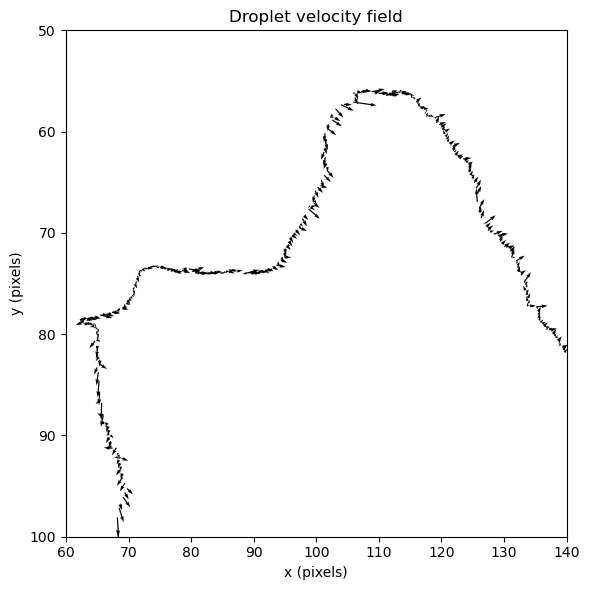

Analysis complete.


In [ ]:
plt.figure(figsize=(6, 6))
plt.quiver(tracks["x"], tracks["y"], tracks["vx"], tracks["vy"])
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.xlim(60, 140)
plt.ylim(50, 100)

plt.title("Droplet velocity field")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Analysis complete.")


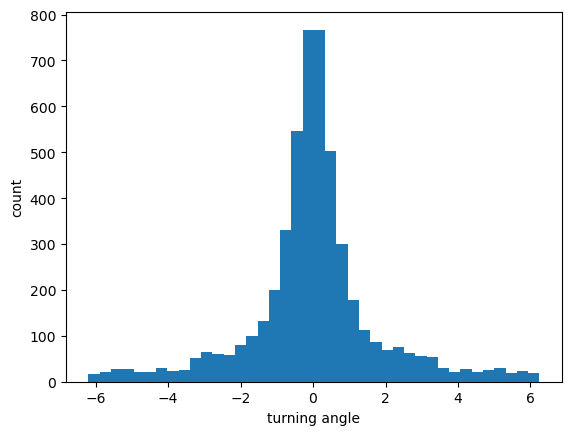

In [17]:
theta = np.arctan2(tracks.vy, tracks.vx)

dtheta = np.diff(theta)

plt.hist(dtheta, bins=40)
plt.xlabel("turning angle")
plt.ylabel("count")
plt.show()


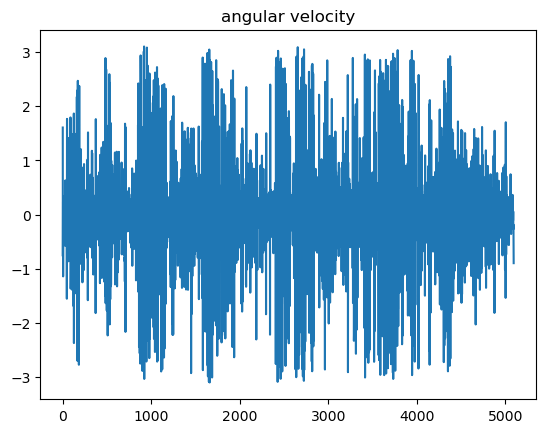

In [19]:
omega = np.gradient(theta)

plt.plot(omega)
plt.title("angular velocity")
plt.show()


Loading trajectory data...
Computing pair interactions...
Plotting interaction force...


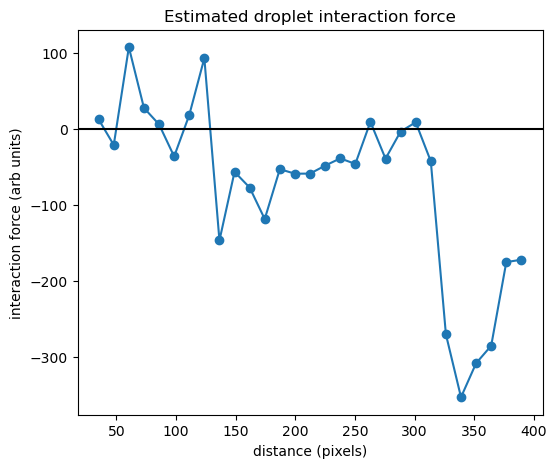

Done.


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

print("Loading trajectory data...")
tracks = pd.read_csv("droplet_trajectories.csv")

# convert to tensor
frames = torch.tensor(tracks["frame"].values)
particles = torch.tensor(tracks["particle"].values)
x = torch.tensor(tracks["x"].values, dtype=torch.float32)
y = torch.tensor(tracks["y"].values, dtype=torch.float32)

# velocity
vx = torch.diff(x, prepend=x[:1])
vy = torch.diff(y, prepend=y[:1])

# acceleration
ax = torch.diff(vx, prepend=vx[:1])
ay = torch.diff(vy, prepend=vy[:1])

tracks["ax"] = ax.numpy()
tracks["ay"] = ay.numpy()

print("Computing pair interactions...")

distances = []
forces = []

for frame in tracks.frame.unique():
    f = tracks[tracks.frame == frame]

    if len(f) < 2:
        continue

    # Keep all vectors in float32 to avoid dtype mismatch in torch.dot
    pos = torch.tensor(f[["x", "y"]].values, dtype=torch.float32)
    acc = torch.tensor(f[["ax", "ay"]].values, dtype=torch.float32)

    N = pos.shape[0]

    for i in range(N):
        for j in range(i + 1, N):
            r_vec = pos[j] - pos[i]
            r = torch.norm(r_vec)

            if r < 1:
                continue

            r_hat = (r_vec / r).to(torch.float32)

            # project acceleration onto interaction direction
            a_rel = torch.dot((acc[i] - acc[j]).to(torch.float32), r_hat)

            distances.append(r.item())
            forces.append(a_rel.item())

distances = np.array(distances)
forces = np.array(forces)

d = {"distance": distances, "force": forces}

df = pd.DataFrame(d)
df.to_csv("force_distance_data.csv")

print("Plotting interaction force...")

bins = np.linspace(distances.min(), distances.max(), 30)
bin_centers = (bins[:-1] + bins[1:]) / 2

force_avg = []

for i in range(len(bins) - 1):
    mask = (distances > bins[i]) & (distances < bins[i + 1])

    if np.sum(mask) > 5:
        force_avg.append(np.mean(forces[mask]))
    else:
        force_avg.append(np.nan)

plt.figure(figsize=(6, 5))
plt.plot(bin_centers, force_avg, "-o")
plt.axhline(0, color="black")
plt.xlabel("distance (pixels)")
plt.ylabel("interaction force (arb units)")
plt.title("Estimated droplet interaction force")
plt.show()

print("Done.")


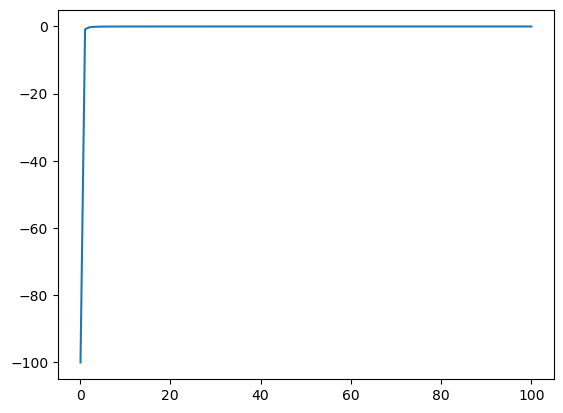

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.1, 100, 100)
y = (x**3) * np.exp(-x) * np.sin(x)
lambda_ = 0.01
A = 0.01
B = 1
y = A * np.exp(-x / lambda_) - (B / x**2)
plt.plot(x, y)


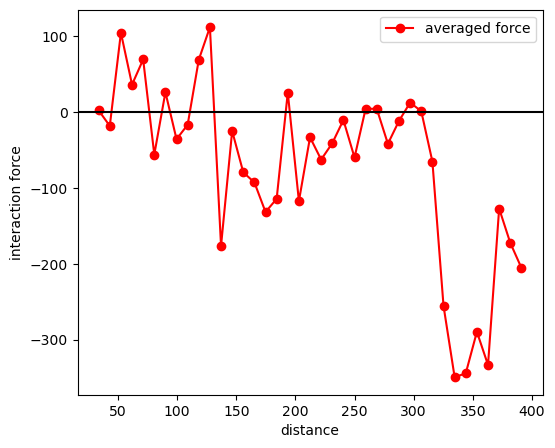

In [ ]:
distances = np.array(distances)
forces = np.array(forces)

bins = np.linspace(distances.min(), distances.max(), 40)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

force_avg = []
force_std = []

for i in range(len(bins) - 1):
    mask = (distances >= bins[i]) & (distances < bins[i + 1])

    if np.sum(mask) > 10:
        force_avg.append(np.mean(forces[mask]))
        force_std.append(np.std(forces[mask]))
    else:
        force_avg.append(np.nan)
        force_std.append(np.nan)

force_avg = np.array(force_avg)

plt.figure(figsize=(6, 5))

plt.plot(bin_centers, force_avg, "r-o", label="averaged force")

plt.axhline(0, color="black")

plt.xlabel("distance")
plt.ylabel("interaction force")
plt.legend()

plt.show()
